In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date
from dateutil.relativedelta import relativedelta
import yfinance as yf
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [3]:

training_dataset = pd.read_csv("/content/drive/MyDrive/data sets for  ml/csv_files for creat dataset/training_dataset.csv")
training_dataset

,Date,Close,High,Low,Open,Volume,Sentiment
0,2021-04-15,14581.450195,14597.549805,14353.200195,14522.400391,568000,-1
1,2021-04-16,14617.849609,14697.700195,14559.000000,14599.599609,577200,1
2,2021-04-19,14359.450195,14382.299805,14191.400391,14306.599609,512300,-1
3,2021-04-20,14296.400391,14526.950195,14207.299805,14526.700195,467400,-1
4,2021-04-22,14406.150391,14424.750000,14151.400391,14219.150391,524600,-1
...,...,...,...,...,...,...,...
366,2022-10-06,17331.800781,17428.800781,17315.650391,17379.250000,265500,1
367,2022-10-07,17314.650391,17337.349609,17216.949219,17287.199219,216300,1
368,2022-10-10,17241.000000,17280.150391,17064.699219,17094.349609,234000,-1
369,2022-10-11,16983.550781,17261.800781,16950.300781,17256.050781,282600,1


In [4]:

df = training_dataset[['Open', 'Close', 'Volume', 'Sentiment']]
df['Open'] = df['Open'].shift(-1)
df.drop(df.tail(1).index,inplace=True)
df


,Open,Close,Volume,Sentiment
0,14599.599609,14581.450195,568000,-1
1,14306.599609,14617.849609,577200,1
2,14526.700195,14359.450195,512300,-1
3,14219.150391,14296.400391,467400,-1
4,14326.349609,14406.150391,524600,-1
...,...,...,...,...
365,17379.250000,17274.300781,226000,-1
366,17287.199219,17331.800781,265500,1
367,17094.349609,17314.650391,216300,1
368,17256.050781,17241.000000,234000,-1


In [5]:

X = df[['Close', 'Volume', 'Sentiment']]
sc = MinMaxScaler(feature_range=(0,1))
X = sc.fit_transform(X)

y = df['Open'].values
sc2 = MinMaxScaler(feature_range=(0,1))
y = y.reshape(-1, 1)
y = sc2.fit_transform(y)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle = False, stratify = None)

In [7]:

# Build the LSTM model
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape= (X_train.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

# Train the model
model.fit(X_train, y_train, batch_size=1, epochs=15)

Epoch 1/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0272 - mean_absolute_error: 0.1168
Epoch 2/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0050 - mean_absolute_error: 0.0546
Epoch 3/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0034 - mean_absolute_error: 0.0454
Epoch 4/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0025 - mean_absolute_error: 0.0392
Epoch 5/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0029 - mean_absolute_error: 0.0415
Epoch 6/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0023 - mean_absolute_error: 0.0374
Epoch 7/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0029 - mean_absolute_error: 0.0424
Epoch 8/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0027 - mean_absolute_error: 0.0400
Epoch 9/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0023 - mean_absolute_error: 0.0360
Epoch 10/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0015 - mean_absolute_error: 0.0298
Epoch 11/15
296/296 ━━━━━━━━━

In [7]:
pip install --upgrade scikit-learn

In [8]:
y_pred = model.predict(X_test)
y_pred = sc2.inverse_transform(y_pred)
y_true = sc2.inverse_transform(y_test)

#from sklearn.metrics import mean_squared_error

#mean_squared_error(y_true, y_pred, squared=False)

from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(rmse)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step
144.5988752874251


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


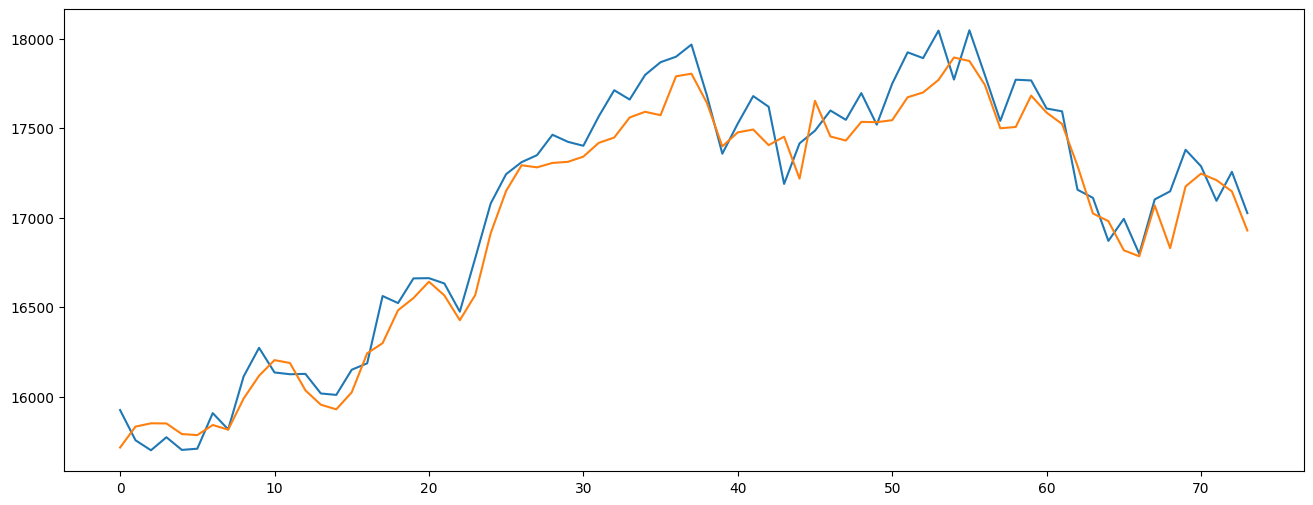

In [9]:

y_pred = model.predict(X_test)
y_pred = sc2.inverse_transform(y_pred)
y_true = sc2.inverse_transform(y_test)
# Visualize the data

plt.figure(figsize=(16,6))
plt.plot(y_true)
plt.plot(y_pred)
plt.show()


In [10]:
from sklearn.metrics import r2_score
r2_score(y_true, y_pred)

0.9577234612595791

In [11]:

open = []
for i in y_test:
  open.append(i[0])
len(open)

74

In [12]:

data = pd.DataFrame()
data['open'] = open
data['Open PCT'] = data['open'].pct_change(1)
data.dropna(inplace=True)
data

,open,Open PCT
1,0.350954,-0.098855
2,0.338235,-0.036241
3,0.354843,0.049104
4,0.338691,-0.045520
5,0.340242,0.004580
...,...,...
69,0.720957,0.079159
70,0.699957,-0.029129
71,0.655959,-0.062857
72,0.692850,0.056240


In [13]:

amount = 1000
new_arr1 = []
og_x = data['Open PCT'].values
for i in og_x:
  amount = amount + (amount*i)
  if i>0:
    new_arr1.append(1)
  else:
    new_arr1.append(0)
amount


np.float64(1644.0061578278037)

In [14]:
open_predict = []
for i in y_pred:
  open_predict.append(i[0])
print(len(open_predict))

data2 = pd.DataFrame()
data2['open predict'] = open_predict
data2['Open predict PCT'] = data2['open predict'].pct_change(1)
data2.dropna(inplace=True)
data2


74


,open predict,Open predict PCT
1,15833.829102,0.007425
2,15852.221680,0.001162
3,15851.475586,-0.000047
4,15792.301758,-0.003733
5,15786.367188,-0.000376
...,...,...
69,17174.800781,0.020473
70,17246.107422,0.004152
71,17209.894531,-0.002100
72,17146.927734,-0.003659


In [15]:

new_arr2 = []
amount = 1000
x = data2['Open predict PCT'].values
for i in range(len(x)):
  if x[i]>0:
    amount = amount + (amount*og_x[i])
    new_arr2.append(1)
  else:
    new_arr2.append(0)
amount


np.float64(3582.5550242511604)

In [16]:

new_df = pd.DataFrame()
new_df['Og'] = new_arr1
new_df['pred'] = new_arr2
new_df

,Og,pred
0,0,1
1,0,1
2,1,0
3,0,0
4,1,0
...,...,...
68,1,1
69,0,1
70,0,0
71,1,0


In [17]:
new_df[new_df['Og'] == new_df['pred']]

,Og,pred
3,0,0
5,1,1
6,0,0
7,1,1
8,1,1
10,0,0
12,0,0
13,0,0
14,1,1
15,1,1
